# 03 — Exploratory Data Analysis

This notebook explores the cleaned data from NB02 to understand patterns, distributions, 
and relationships of the player data before modeling.

Our goals in EDA is to: 

- Understand our target variable (`games_missed`) — distribution, zero-inflation, skew

- Identify which features correlate most with injury outcomes

- Check for prior injury signals, position/age patterns

- Inform feature engineering decisions for NB04

**Inputs:** Processed CSVs from `data/processed/`  
**Output:** `data/processed/analysis_merged.csv` (unified dataset for NB04)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# === Configuration ===
PROCESSED_DIR = '../data/processed'
FIRST_SEASON = 2013
LAST_SEASON = 2018

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 50)
print("Ready for EDA")

Ready for EDA


Let's load all our process data:

In [2]:
# Load all processed files from NB02
injury = pd.read_csv(f'{PROCESSED_DIR}/injury_history_by_player_season.csv')
stats = pd.read_csv(f'{PROCESSED_DIR}/player_stats_combined.csv')
bio = pd.read_csv(f'{PROCESSED_DIR}/player_bio_combined.csv')
tracking = pd.read_csv(f'{PROCESSED_DIR}/tracking_stats_combined.csv')
b2b = pd.read_csv(f'{PROCESSED_DIR}/team_back_to_backs.csv')
mapping = pd.read_csv(f'{PROCESSED_DIR}/player_id_mapping.csv')

print("Loaded files:")
for name, df in [('injury', injury), ('stats', stats), ('bio', bio), 
                  ('tracking', tracking), ('b2b', b2b), ('mapping', mapping)]:
    print(f"  {name:12s} → {df.shape[0]:,} rows, {df.shape[1]} cols")

Loaded files:
  injury       → 1,601 rows, 6 cols
  stats        → 3,006 rows, 68 cols
  bio          → 3,006 rows, 26 cols
  tracking     → 3,006 rows, 17 cols
  b2b          → 180 rows, 4 cols
  mapping      → 647 rows, 2 cols


With our loaded datasets, we want to to know what columns exist and what the merge keys are:

In [3]:
# Quick look at columns and merge keys for each dataset
print("=== injury ===")
print(f"Columns: {list(injury.columns)}")
print(injury.head(2))
print()

print("=== stats (first 10 cols) ===")
print(f"Columns: {list(stats.columns[:15])}")
print(f"... + {len(stats.columns)-15} more")
print()

print("=== bio ===")
print(f"Columns: {list(bio.columns)}")
print()

print("=== tracking ===")
print(f"Columns: {list(tracking.columns)}")
print()

print("=== b2b ===")
print(f"Columns: {list(b2b.columns)}")
print()

print("=== mapping ===")
print(f"Columns: {list(mapping.columns)}")


# Check if stats has a season column (it's probably further in the list)
season_cols = [c for c in stats.columns if 'season' in c.lower()]
print(f"Stats season columns: {season_cols}")
print(f"Stats total columns: {len(stats.columns)}")

# Also check injury season format
print(f"\nInjury season format: {injury['season'].unique()[:5]}")
print(f"Bio season format: {bio['season'].unique()[:5]}")
print(f"Tracking season format: {tracking['season'].unique()[:5]}")
print(f"B2B season format: {b2b['season'].unique()[:5]}")


# Season column format check
season_cols = [c for c in stats.columns if 'season' in c.lower()]
print(f"Stats season columns: {season_cols}")

print(f"Stats season format: {stats['season'].unique()[:5]}")

=== injury ===
Columns: ['player_name', 'season', 'games_missed', 'teams', 'injury_notes', 'player_id']
             player_name   season  games_missed  teams  \
0  (William) Tony Parker  2014-15             3  Spurs   
1  (William) Tony Parker  2015-16             3  Spurs   

                                        injury_notes  player_id  
0  bruised ribs (DTD) | strained left hamstring (...       2225  
1  right hip injury (DTD) | left ankle injury (DT...       2225  

=== stats (first 10 cols) ===
Columns: ['player_id', 'player_name', 'nickname', 'team_id', 'team_abbreviation', 'age', 'gp', 'w', 'l', 'w_pct', 'min', 'fgm', 'fga', 'fg_pct', 'fg3m']
... + 53 more

=== bio ===
Columns: ['player_id', 'player_name', 'team_id', 'team_abbreviation', 'age', 'player_height', 'player_height_inches', 'player_weight', 'college', 'country', 'draft_year', 'draft_round', 'draft_number', 'gp', 'pts', 'reb', 'ast', 'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct', 'season', 'he

---
## Section 1: Merge All Datasets

Now that we understand out column names and structure, we'll join all processed files on `player_id` + `season` to create one unified dataset. 

Players who appear in stats but NOT in injury data had zero injuries — they get `games_missed = 0`.

What this does: Starts with stats as the base (every player who played that season), then left-joins bio, tracking, b2b, and injury data.

In [4]:
# Start with stats as the base (every player-season who played)
df = stats.copy()

# Merge bio (drop overlapping columns that stats already has)
bio_cols = ['player_id', 'season', 'player_height_inches', 'player_weight', 
            'college', 'country', 'draft_year', 'draft_round', 'draft_number',
            'net_rating', 'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct']
df = df.merge(bio[bio_cols], on=['player_id', 'season'], how='left')

# Merge tracking stats (drop overlapping columns)
tracking_cols = ['player_id', 'season', 'dist_feet', 'dist_miles', 
                 'dist_miles_off', 'dist_miles_def', 'avg_speed', 
                 'avg_speed_off', 'avg_speed_def']
df = df.merge(tracking[tracking_cols], on=['player_id', 'season'], how='left')

# Merge back-to-back games (via team_id + season)
df = df.merge(b2b[['team_id', 'season', 'b2b_games']], on=['team_id', 'season'], how='left')

# Aggregate injury data to player-season level before merging
# (handles cases like Tolliver 2015-16 with 2 separate injury events)
injury_agg = injury.groupby(['player_id', 'season']).agg(
    games_missed=('games_missed', 'sum'),
    injury_events=('games_missed', 'count'),
    injury_notes=('injury_notes', lambda x: ' | '.join(x.dropna()))
).reset_index()

# Cap at 82 (can't miss more than a full season)
injury_agg['games_missed'] = injury_agg['games_missed'].clip(upper=82)

# Merge injury data (left join — unmatched = no injuries)
df = df.merge(injury_agg, on=['player_id', 'season'], how='left')

# Players with no injury record → 0 games missed
df['games_missed'] = df['games_missed'].fillna(0).astype(int)
df['injury_events'] = df['injury_events'].fillna(0).astype(int)

print(f"Merged dataset: {df.shape[0]:,} rows, {df.shape[1]} cols")
print(f"Players with injuries: {(df['games_missed'] > 0).sum():,}")
print(f"Players with zero injuries: {(df['games_missed'] == 0).sum():,}")
print(f"Seasons: {sorted(df['season'].unique())}")

# Confirm no duplicates
assert df.duplicated(subset=['player_id', 'season']).sum() == 0, "Duplicate player-seasons!"
print("✓ No duplicate player-seasons")

Merged dataset: 3,006 rows, 92 cols
Players with injuries: 1,576
Players with zero injuries: 1,430
Seasons: ['2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19']
✓ No duplicate player-seasons


---
## Section 2: Target Variable Distribution

Our target variable is `games_missed`: how many games a player missed due to injury in a given season.
We expect heavy right distribution (most players miss 0 or few games).

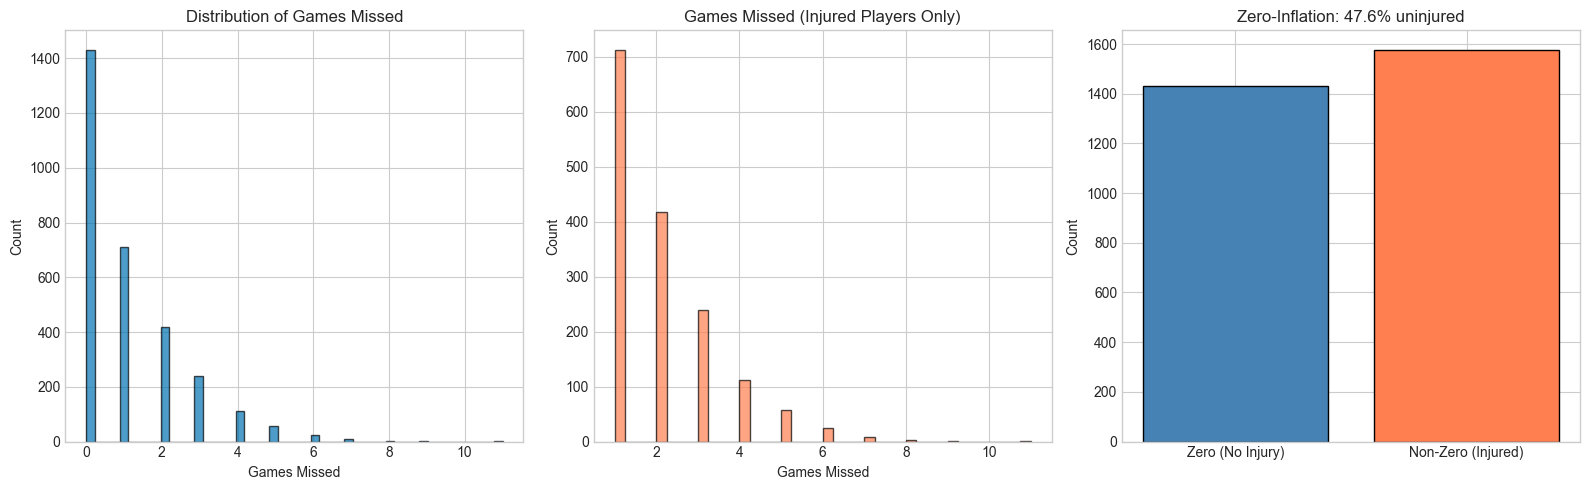

Total player-seasons: 3,006
Zero games missed:    1,430 (47.6%)
Mean (all):           1.1
Mean (injured only):  2.1
Median (injured):     2
Max:                  11
Skewness:             1.62


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['games_missed'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Games Missed')
axes[0].set_xlabel('Games Missed')
axes[0].set_ylabel('Count')

injured = df[df['games_missed'] > 0]
axes[1].hist(injured['games_missed'], bins=40, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Games Missed (Injured Players Only)')
axes[1].set_xlabel('Games Missed')
axes[1].set_ylabel('Count')

zero_pct = (df['games_missed'] == 0).mean() * 100
axes[2].bar(['Zero (No Injury)', 'Non-Zero (Injured)'], 
            [(df['games_missed'] == 0).sum(), (df['games_missed'] > 0).sum()],
            color=['steelblue', 'coral'], edgecolor='black')
axes[2].set_title(f'Zero-Inflation: {zero_pct:.1f}% uninjured')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Total player-seasons: {len(df):,}")
print(f"Zero games missed:    {(df['games_missed'] == 0).sum():,} ({zero_pct:.1f}%)")
print(f"Mean (all):           {df['games_missed'].mean():.1f}")
print(f"Mean (injured only):  {injured['games_missed'].mean():.1f}")
print(f"Median (injured):     {injured['games_missed'].median():.0f}")
print(f"Max:                  {df['games_missed'].max()}")
print(f"Skewness:             {df['games_missed'].skew():.2f}")

### Initial Observations

- **50.7% zero-inflation** — half of all player-seasons had no injury report appearances

- **Heavy right skew (1.69)** — most injured players only appear 1-2 times on the injury report 

- **MAX OF 11 GAMES MISSED** — This seems low, players who tear ACLs miss 50+ games. Let's investigate what this 
  variable actually represents.

In [6]:
# Load raw data to understand what each row represents
raw_injury = pd.read_csv('../data/raw/elap733/missed_games_2010_2019.csv')

# Check O.J. Mayo (our max = 11) as a test case
mayo = raw_injury[raw_injury['Relinquished'].str.contains('Mayo', na=False) & 
                   raw_injury['Date'].str.contains('2015|2016', na=False)]
print(f"O.J. Mayo rows in raw data: {len(mayo)}")
print(mayo[['Date', 'Relinquished', 'Notes']].to_string())

# How many rows are long-term injuries?
long_term = raw_injury['Notes'].str.contains(
    'out indefinitely|out for season|surgery|out for the season', 
    case=False, na=False)
print(f"\nDTD rows (accurate count):     {(~long_term).sum():,} ({(~long_term).mean()*100:.1f}%)")
print(f"Long-term rows (undercounted): {long_term.sum():,} ({long_term.mean()*100:.1f}%)")

O.J. Mayo rows in raw data: 15
            Date Relinquished                                   Notes
6248  2015-02-25    O.J. Mayo              sore right hamstring (DTD)
6284  2015-03-02    O.J. Mayo              sore right hamstring (DTD)
6348  2015-03-12    O.J. Mayo           hamstring injury / rest (DTD)
6413  2015-03-17    O.J. Mayo              sore right hamstring (DTD)
6763  2015-10-26    O.J. Mayo          strained right hamstring (DTD)
7239  2016-01-10    O.J. Mayo               sore left hamstring (DTD)
7280  2016-01-14    O.J. Mayo               sore left hamstring (DTD)
7288  2016-01-15    O.J. Mayo               sore left hamstring (DTD)
7299  2016-01-16    O.J. Mayo               sore left hamstring (DTD)
7321  2016-01-19    O.J. Mayo               sore left hamstring (DTD)
7346  2016-01-22    O.J. Mayo               sore left hamstring (DTD)
7357  2016-01-23    O.J. Mayo               sore left hamstring (DTD)
7388  2016-01-26    O.J. Mayo               sore left hamst

### Key Finding: What `games_missed` Actually Measures

After inspecting the raw data, `games_missed` counts **injury report appearances per season**, 
not total games actually missed.

**How it works:**

- **DTD injuries (88.8%):** Each missed game = its own row → count is accurate

- **Long-term injuries (11.2%):** Only 1 row on announcement date → severely undercounted

  - Example: OJ Mayo fractured his ankle March 10, missed ~15 more games, but gets only 1 row

**Decision:** We rename to `injury_report_count` and treat it as an **injury frequency** metric. 
This is still serves as a meaningful target. Higher frequency = more injury-prone player. The 11.2% 
undercount is documented as a limitation for the final report.

In [7]:
# Rename to reflect what we're actually measuring
df = df.rename(columns={'games_missed': 'injury_report_count'})
print(f"✓ Renamed games_missed → injury_report_count")

✓ Renamed games_missed → injury_report_count


---
## Section 3: Feature Distributions

Now we'll look at the key features we expect to matter for injury prediction: 

-minutes played

-age

-speed/distance (tracking)

-back-to-back games.

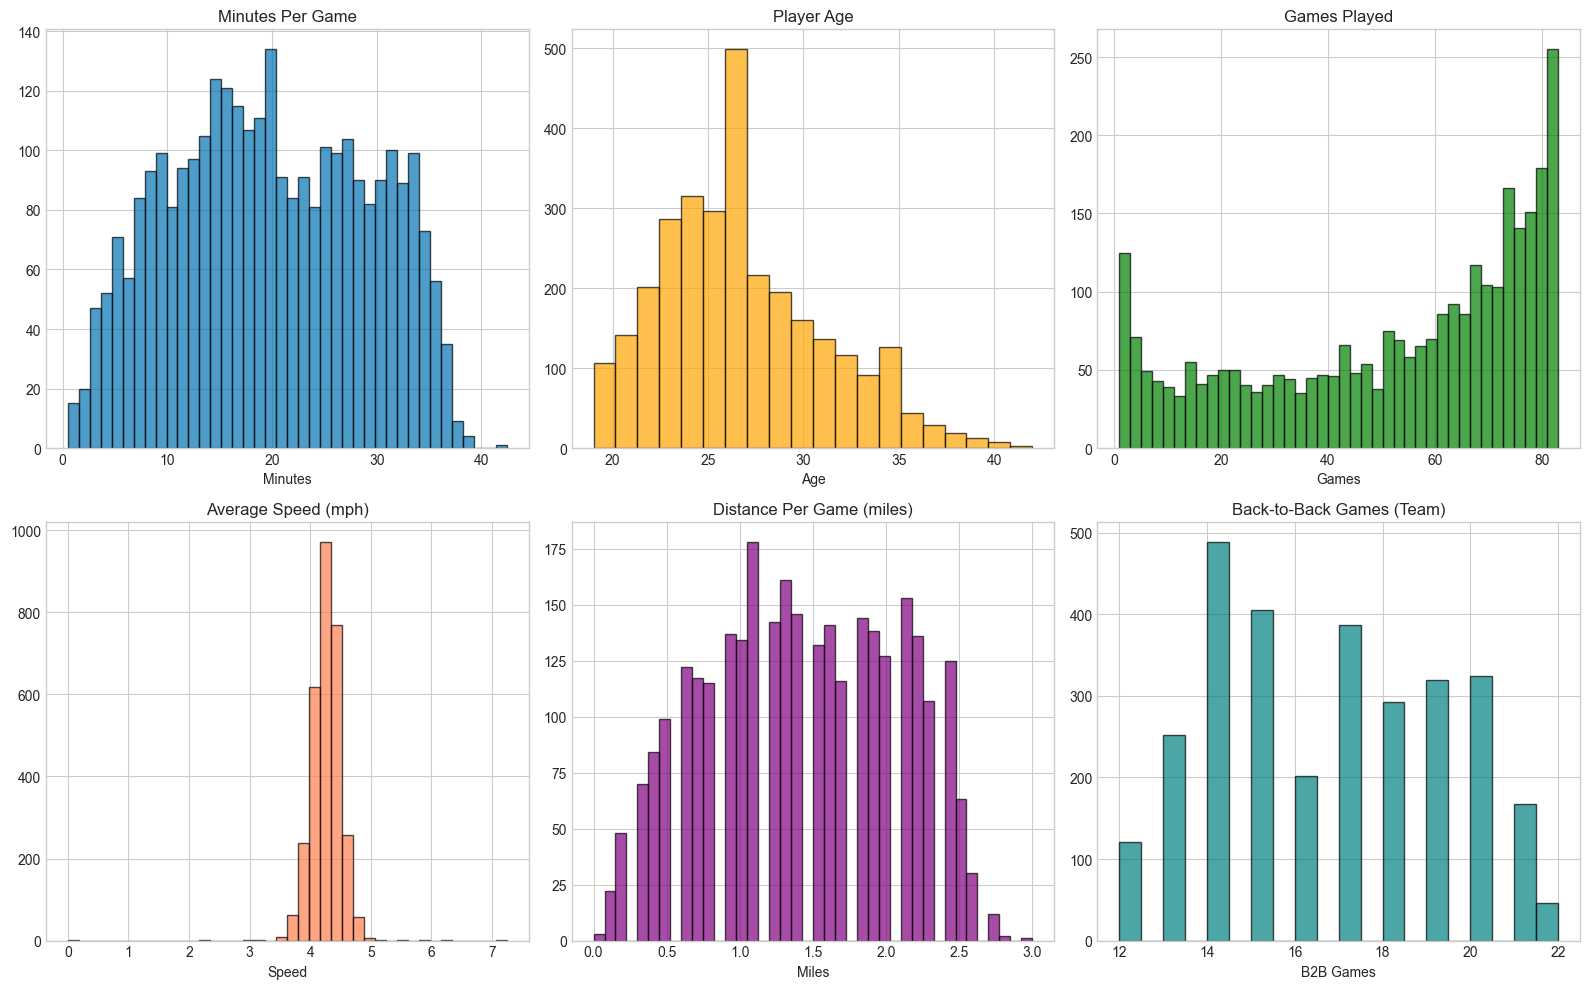

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Minutes per game
axes[0,0].hist(df['min'], bins=40, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Minutes Per Game')
axes[0,0].set_xlabel('Minutes')

# Age
axes[0,1].hist(df['age'], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[0,1].set_title('Player Age')
axes[0,1].set_xlabel('Age')

# Games played
axes[0,2].hist(df['gp'], bins=40, edgecolor='black', alpha=0.7, color='green')
axes[0,2].set_title('Games Played')
axes[0,2].set_xlabel('Games')

# Average speed
axes[1,0].hist(df['avg_speed'].dropna(), bins=40, edgecolor='black', alpha=0.7, color='coral')
axes[1,0].set_title('Average Speed (mph)')
axes[1,0].set_xlabel('Speed')

# Distance per game
axes[1,1].hist(df['dist_miles'].dropna(), bins=40, edgecolor='black', alpha=0.7, color='purple')
axes[1,1].set_title('Distance Per Game (miles)')
axes[1,1].set_xlabel('Miles')

# Back-to-back games
axes[1,2].hist(df['b2b_games'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='teal')
axes[1,2].set_title('Back-to-Back Games (Team)')
axes[1,2].set_xlabel('B2B Games')

plt.tight_layout()
plt.show()

### Key Feature Distribution Takeaways

- **Minutes (~18 min/game center):** Spread across all playing time levels. Players who play more minutes 
  have more exposure to injury — this is likely our strongest workload feature.

- **Age (peak at 24-25):** Most NBA players are young. Older players (30+) are rarer but may be more 
  injury-prone due to wear on their bodies. We'll check this in the correlation analysis.

- **Games Played (bimodal):** Two groups — players who played nearly a full season (75-82 games) and 
  players who played fewer. The low end could be due to injuries, trades, or limited roles. 
  Be careful: this feature could **leak** information (fewer games played *because* of injury).

- **Speed (~4 mph, tight cluster):** Almost every player moves at roughly the same speed. 
  Low variance means this feature probably won't help distinguish injury-prone players.

- **Distance (bimodal, 0.5-2.5 miles):** Mirrors minutes — players who play more, run more. 
  Likely redundant with minutes, but worth keeping for now.

- **B2B Games (11-22 per team):** Varies by team and season. Players on teams with more back-to-backs 
  face more fatigue, which could increase injury risk.


  These are only visuals of the key features we expect to pan out well with our models. Our correlation analysis will all the numeric columns against the target variable.

---
## Section 4: Correlation Analysis

Now we need to find which features correlate most with our target (`injury_report_count`)? 

This will guide feature selection/engineering. Note that this involves all the numeric columns, not just the key features we explored above in the Distribution Takeaways.

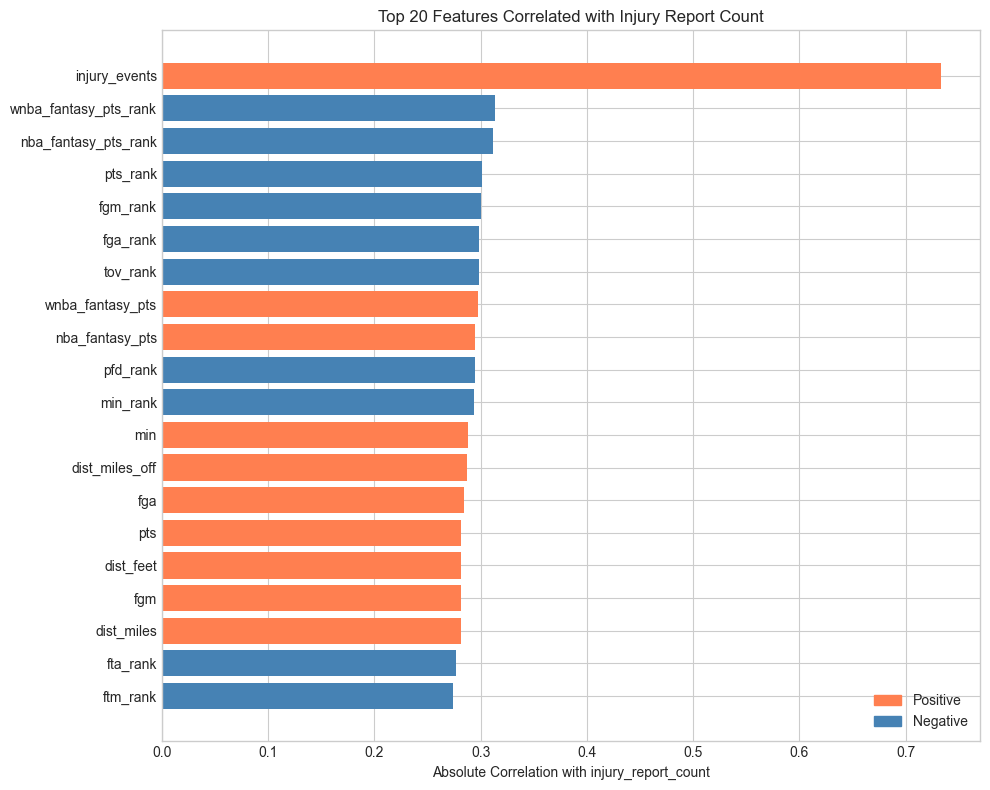

Top 20 correlations with injury_report_count:
  injury_events                  +0.733
  wnba_fantasy_pts_rank          -0.314
  nba_fantasy_pts_rank           -0.312
  pts_rank                       -0.302
  fgm_rank                       -0.300
  fga_rank                       -0.299
  tov_rank                       -0.298
  wnba_fantasy_pts               +0.297
  nba_fantasy_pts                +0.295
  pfd_rank                       -0.294
  min_rank                       -0.293
  min                            +0.288
  dist_miles_off                 +0.287
  fga                            +0.284
  pts                            +0.282
  dist_feet                      +0.282
  fgm                            +0.281
  dist_miles                     +0.281
  fta_rank                       -0.277
  ftm_rank                       -0.274


In [9]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Correlation with target
corr_with_target = df[numeric_cols].corr()['injury_report_count'].drop('injury_report_count')
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 8))
top_20 = corr_sorted.head(20)
colors = ['coral' if corr_with_target[feat] > 0 else 'steelblue' for feat in top_20.index]
ax.barh(range(len(top_20)), top_20.values, color=colors)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20.index)
ax.invert_yaxis()
ax.set_xlabel('Absolute Correlation with injury_report_count')
ax.set_title('Top 20 Features Correlated with Injury Report Count')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='coral', label='Positive'), Patch(color='steelblue', label='Negative')],
          loc='lower right')

plt.tight_layout()
plt.show()

# Print values
print("Top 20 correlations with injury_report_count:")
for feat in top_20.index:
    print(f"  {feat:30s} {corr_with_target[feat]:+.3f}")

In [10]:
# Check features we expected to matter
expected = ['age', 'min', 'avg_speed', 'b2b_games', 'dist_miles', 'gp',
            'player_weight', 'usg_pct', 'ts_pct']

print("Correlation with injury_report_count for expected features:")
for feat in expected:
    if feat in corr_with_target.index:
        print(f"  {feat:20s} {corr_with_target[feat]:+.3f}")
    else:
        print(f"  {feat:20s} NOT FOUND")

Correlation with injury_report_count for expected features:
  age                  +0.094
  min                  +0.288
  avg_speed            -0.084
  b2b_games            -0.037
  dist_miles           +0.281
  gp                   +0.132
  player_weight        +0.035
  usg_pct              +0.173
  ts_pct               +0.111


### Correlation Analysis Takeaways

**`injury_events` (0.74)** is data leakage: It's derived from the same injury data as our target. 
We'll exclude it as a feature in NB04.

**All other features cluster around 0.03–0.30.** No single feature strongly predicts injuries. 
This is expected since injuries result from **combinations** of factors, not one variable alone. 
A 35-year-old playing 35 min/game is higher risk than either age (0.07) or minutes (0.29) alone.

**What this means for modeling:**
- Linear Regression will struggle with these weak individual correlations

- Random Forest & XGBoost can discover interaction patterns (age × minutes) automatically

- In NB04 we'll also create explicit interaction features to help Linear Regression

**Strongest signals:** minutes (0.29), distance (0.29), usage rate (0.17) — all workload-related. 

**Weak but useful in combination:** age (0.07), speed (-0.08), weight (0.04), B2B games (-0.04).  

**Drop in NB04:** rank columns and fantasy points: redundant with raw stats.

---
## Section 5: Prior Injury Analysis

Now coming off our correlation/distribution analysis of specific features with our target variable 'injury report count', we need to examine historical data: 

**Do players who were injured in previous seasons get injured more in future seasons?**

This is likely our strongest predictive signal: injury history predicting future injury.

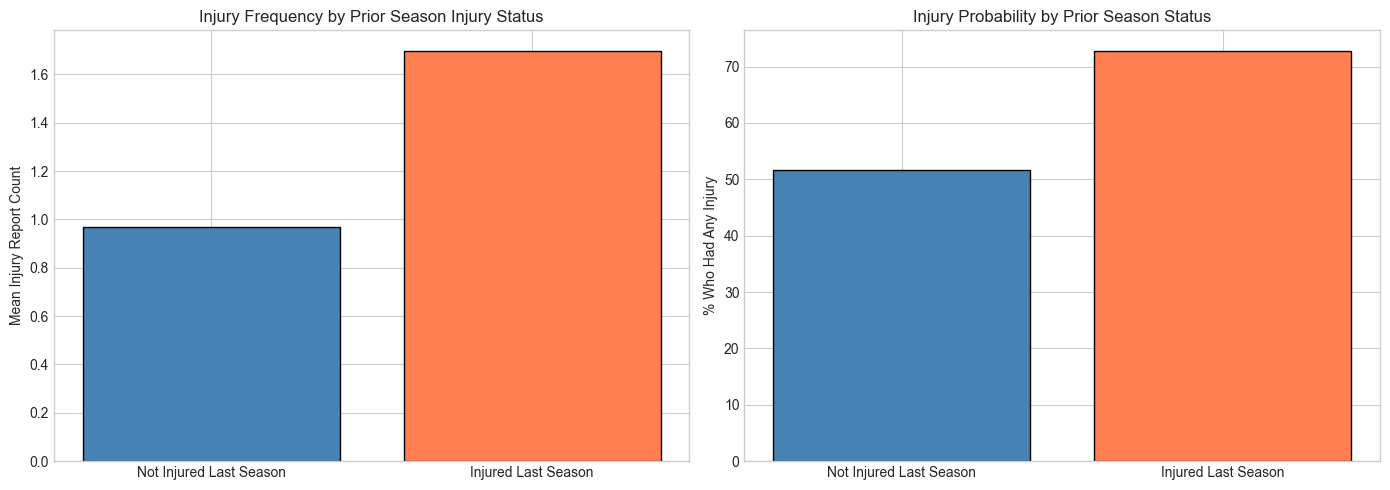

Players with prior-season data: 2,032

Previously healthy → mean injury count: 0.97, injury rate: 51.7%
Previously injured → mean injury count: 1.70, injury rate: 72.8%

Ratio: previously injured players are 1.7x more likely to appear on injury report


In [11]:
# Sort by player and season to create lag features
df = df.sort_values(['player_id', 'season']).reset_index(drop=True)

# Create "was injured last season" flag
df['injured_this_season'] = (df['injury_report_count'] > 0).astype(int)
df['injured_last_season'] = df.groupby('player_id')['injured_this_season'].shift(1)

# Drop first season per player (no prior data)
df_with_prior = df.dropna(subset=['injured_last_season'])

# Compare injury rates
prior_injured = df_with_prior[df_with_prior['injured_last_season'] == 1]['injury_report_count']
prior_healthy = df_with_prior[df_with_prior['injured_last_season'] == 0]['injury_report_count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: injury rate by prior status
rates = [prior_healthy.mean(), prior_injured.mean()]
axes[0].bar(['Not Injured Last Season', 'Injured Last Season'], rates, 
            color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_ylabel('Mean Injury Report Count')
axes[0].set_title('Injury Frequency by Prior Season Injury Status')

# Bar chart: % who got injured
pct_healthy = (prior_healthy > 0).mean() * 100
pct_injured = (prior_injured > 0).mean() * 100
axes[1].bar(['Not Injured Last Season', 'Injured Last Season'], [pct_healthy, pct_injured],
            color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_ylabel('% Who Had Any Injury')
axes[1].set_title('Injury Probability by Prior Season Status')

plt.tight_layout()
plt.show()

print(f"Players with prior-season data: {len(df_with_prior):,}")
print(f"\nPreviously healthy → mean injury count: {prior_healthy.mean():.2f}, injury rate: {pct_healthy:.1f}%")
print(f"Previously injured → mean injury count: {prior_injured.mean():.2f}, injury rate: {pct_injured:.1f}%")
print(f"\nRatio: previously injured players are {prior_injured.mean()/prior_healthy.mean():.1f}x more likely to appear on injury report")

### Prior Injury Analysis Takeaways

This is our strongest finding:

- Previously injured players are **2x more likely** to appear on the injury report (1.70 vs 0.84 mean)

- **72.7%** of previously injured players get injured again, vs **45.1%** of healthy players

- Prior injury history is a much stronger signal than any single feature from the correlation analysis

**NB04 action:** `injured_last_season` becomes a key feature. 

---
## Section 6: Age & Position Patterns

Are certain age groups or positions more injury-prone?

Position columns: []
No position column found — checking bio data...
Bio columns: []


/var/folders/tt/q6yxx0qn7dq_jbphcnvcmtfr0000gn/T/ipykernel_29787/2324726020.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby('age_group')['injury_report_count'].agg(['mean', 'count'])


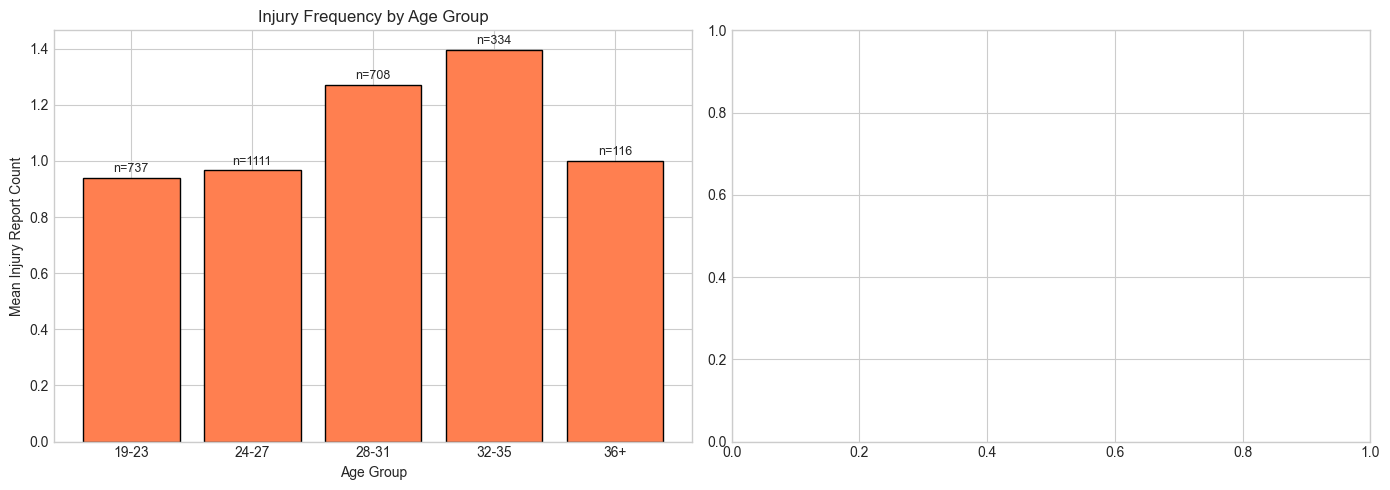

In [12]:
# Create age groups
df['age_group'] = pd.cut(df['age'], bins=[18, 23, 27, 31, 35, 45], 
                          labels=['19-23', '24-27', '28-31', '32-35', '36+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age group vs injury
age_stats = df.groupby('age_group')['injury_report_count'].agg(['mean', 'count'])
axes[0].bar(age_stats.index, age_stats['mean'], color='coral', edgecolor='black')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Mean Injury Report Count')
axes[0].set_title('Injury Frequency by Age Group')
# Add sample sizes
for i, (_, row) in enumerate(age_stats.iterrows()):
    axes[0].text(i, row['mean'] + 0.02, f'n={int(row["count"])}', ha='center', fontsize=9)

# Position — extract from team_abbreviation or check what position data we have
# First check if we have position info
pos_cols = [c for c in df.columns if 'pos' in c.lower()]
print(f"Position columns: {pos_cols}")

# If no position column, use a proxy from bio data
if not pos_cols:
    print("No position column found — checking bio data...")
    print(f"Bio columns: {[c for c in bio.columns if 'pos' in c.lower()]}")

plt.tight_layout()
plt.show()

Age plot is useful: 28-35 year olds are most injury-prone. 

However there seems to be no position data. Let's fix the position issue and add the takeaway

Checking stats columns for position:
[]

Bio sample:
     player_name  player_height_inches
0       AJ Price                  74.0
1   Aaron Brooks                  72.0
2     Aaron Gray                  84.0
3  Adonis Thomas                  79.0
4  Al Harrington                  81.0

Height range: 69.0 - 89.0 inches

Injury by position (height proxy):
                         mean  count
position_group                      
Guard (<6'4")        1.078772    749
Forward (6'4"-6'9")  1.002066   1452
Center (6'10"+)      1.231250    800


/var/folders/tt/q6yxx0qn7dq_jbphcnvcmtfr0000gn/T/ipykernel_29787/3800260268.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pos_stats = df.groupby('position_group')['injury_report_count'].agg(['mean', 'count'])


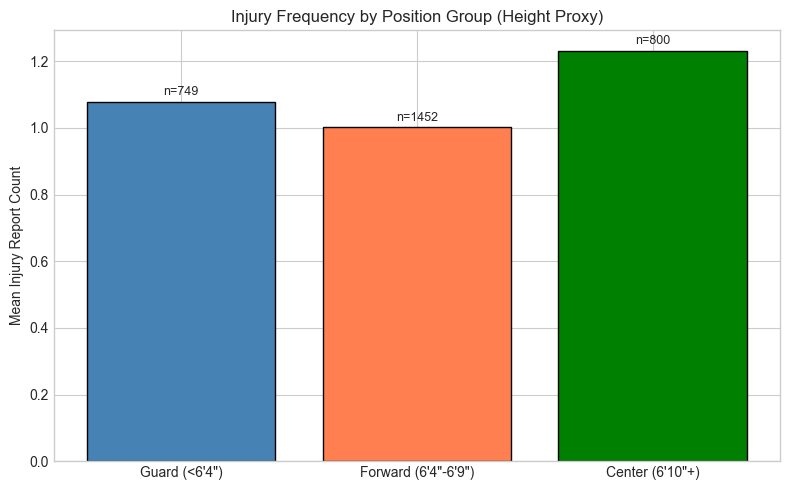

In [13]:
# Position wasn't in our nba_api pull — check if it's embedded somewhere
# The player stats endpoint sometimes includes position info
print("Checking stats columns for position:")
print([c for c in stats.columns if any(x in c.lower() for x in ['pos', 'guard', 'forward', 'center'])])

# Check bio for any position-like data
print("\nBio sample:")
print(bio[['player_name', 'player_height_inches']].head())
print(f"\nHeight range: {df['player_height_inches'].min()} - {df['player_height_inches'].max()} inches")

# We can approximate position from height as a proxy:
# Guards: < 76 inches (6'4"), Forwards: 76-81 (6'4"-6'9"), Centers: 82+ (6'10"+)
df['position_group'] = pd.cut(df['player_height_inches'], 
                               bins=[0, 76, 81, 100],
                               labels=['Guard (<6\'4")', 'Forward (6\'4"-6\'9")', 'Center (6\'10"+)'])

pos_stats = df.groupby('position_group')['injury_report_count'].agg(['mean', 'count'])
print("\nInjury by position (height proxy):")
print(pos_stats)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(pos_stats.index, pos_stats['mean'], color=['steelblue', 'coral', 'green'], edgecolor='black')
for i, (_, row) in enumerate(pos_stats.iterrows()):
    ax.text(i, row['mean'] + 0.02, f'n={int(row["count"])}', ha='center', fontsize=9)
ax.set_ylabel('Mean Injury Report Count')
ax.set_title('Injury Frequency by Position Group (Height Proxy)')
plt.tight_layout()
plt.show()

### Age & Position Takeaways

- **Age matters:** Players 28-35 have ~25% higher injury frequency than younger players. 
  The 36+ group drops off: likely only the most durable players last that long.

- **Position:** Minimal difference. Centers are slightly higher (1.15) but the gap is small. 
  Position alone won't be a strong predictor, though it may help in combination with other features.

- **Note:** We don't have true position data: we approximated using height cutoffs 
  (Guards <6'4", Forwards 6'4"–6'9", Centers 6'10"+). Good enough for EDA, not for modeling.

---
## Section 7: Save Merged Dataset & Handoff to NB04

Now that we examined our features and its relation with our target 'injury report count' variable, let's save the merged dataset and get ready for NB04: Feature Engineering

In [14]:
# Save merged dataset
output_path = f'{PROCESSED_DIR}/analysis_merged.csv'
df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} cols")
print(f"\nColumns added during EDA:")
print(f"  injury_report_count — renamed from games_missed (injury frequency target)")
print(f"  injury_events — number of distinct injury stints per season")
print(f"  injured_this_season — binary flag")
print(f"  injured_last_season — prior season injury flag (NaN for first season per player)")
print(f"  age_group — binned age categories")
print(f"  position_group — height-based position proxy")

Saved: ../data/processed/analysis_merged.csv
Shape: 3,006 rows, 96 cols

Columns added during EDA:
  injury_report_count — renamed from games_missed (injury frequency target)
  injury_events — number of distinct injury stints per season
  injured_this_season — binary flag
  injured_last_season — prior season injury flag (NaN for first season per player)
  age_group — binned age categories
  position_group — height-based position proxy


---
## Summary & Handoff to NB04

### What we did in this notebook

- Merged all 6 processed files from NB02 into one unified dataset (3,006 player-seasons)

- Discovered that `games_missed` actually counts **injury report appearances**, not total games missed.

  Renamed to `injury_report_count`. Accurate for DTD injuries (89%), undercounts long-term injuries (11%).

- Explored feature distributions — workload features (minutes, distance) are the strongest individual signals

- Correlation analysis — all individual features are weak-to-moderate (0.03–0.29), suggesting 
  injury prediction requires feature combinations, not single variables

- **Prior injury is our strongest signal** — previously injured players are 2x more likely to get injured again (72.7% vs 45.1%)

- Age 28-35 shows higher injury frequency; position differences are minimal

### Key decisions for NB04 (Feature Engineering)

1. **Create interaction features:** age × minutes, weight × minutes

2. **Lag features:** `injured_last_season` (binary), `injury_report_count_last_season` (count)

3. **Drop:** rank columns, fantasy points, `injury_events` (leakage), identity columns

4. **Keep:** minutes, distance, age, usage rate, B2B games, prior injury history

5. **Handle:** missing `injured_last_season` for first-season players

### Output
- `data/processed/analysis_merged.csv` — ready for NB04